# Heart Attack in Japan: Youth vs Adult Data Analysis

This notebook performs Exploratory Data Analysis (EDA) and Gaussian Kernel Density Estimation on a dataset regarding heart attack incidents in Japan. It explores the relationships between continuous variables such as Age, Cholesterol Level, Heart Rate, and Blood Pressure, and compares original distributions with newly sampled data using KDE.

In [ ]:
from google.colab import drive
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

In [ ]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset: Heart Attack in Japan Youth Vs Adult

This dataset explores heart attack incidents in Japan, focusing on the differences between youth and adult age groups.

### Continuous variables:

- Age
- Cholesterol_Level: The amount of cholesterol in a human's blood.
- Heart_Rate: The heart rate is the number of times your heart beats per minute
- Systolic_BP: The amount of pressure experienced by the arteries while the heart is beating.
- Diastolic_BP: It is the bottom number in a blood pressure reading

[Dataset link](https://www.kaggle.com/datasets/ashaychoudhary/heart-attack-in-japan-youth-vs-adult)

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Datasets/japan_heart_attack_dataset.csv")
data = data[["Age", "Cholesterol_Level", "Heart_Rate", "Systolic_BP", "Diastolic_BP"]].sample(1000)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 3224 to 1498
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1000 non-null   int64  
 1   Cholesterol_Level  1000 non-null   float64
 2   Heart_Rate         1000 non-null   float64
 3   Systolic_BP        1000 non-null   float64
 4   Diastolic_BP       1000 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 46.9 KB


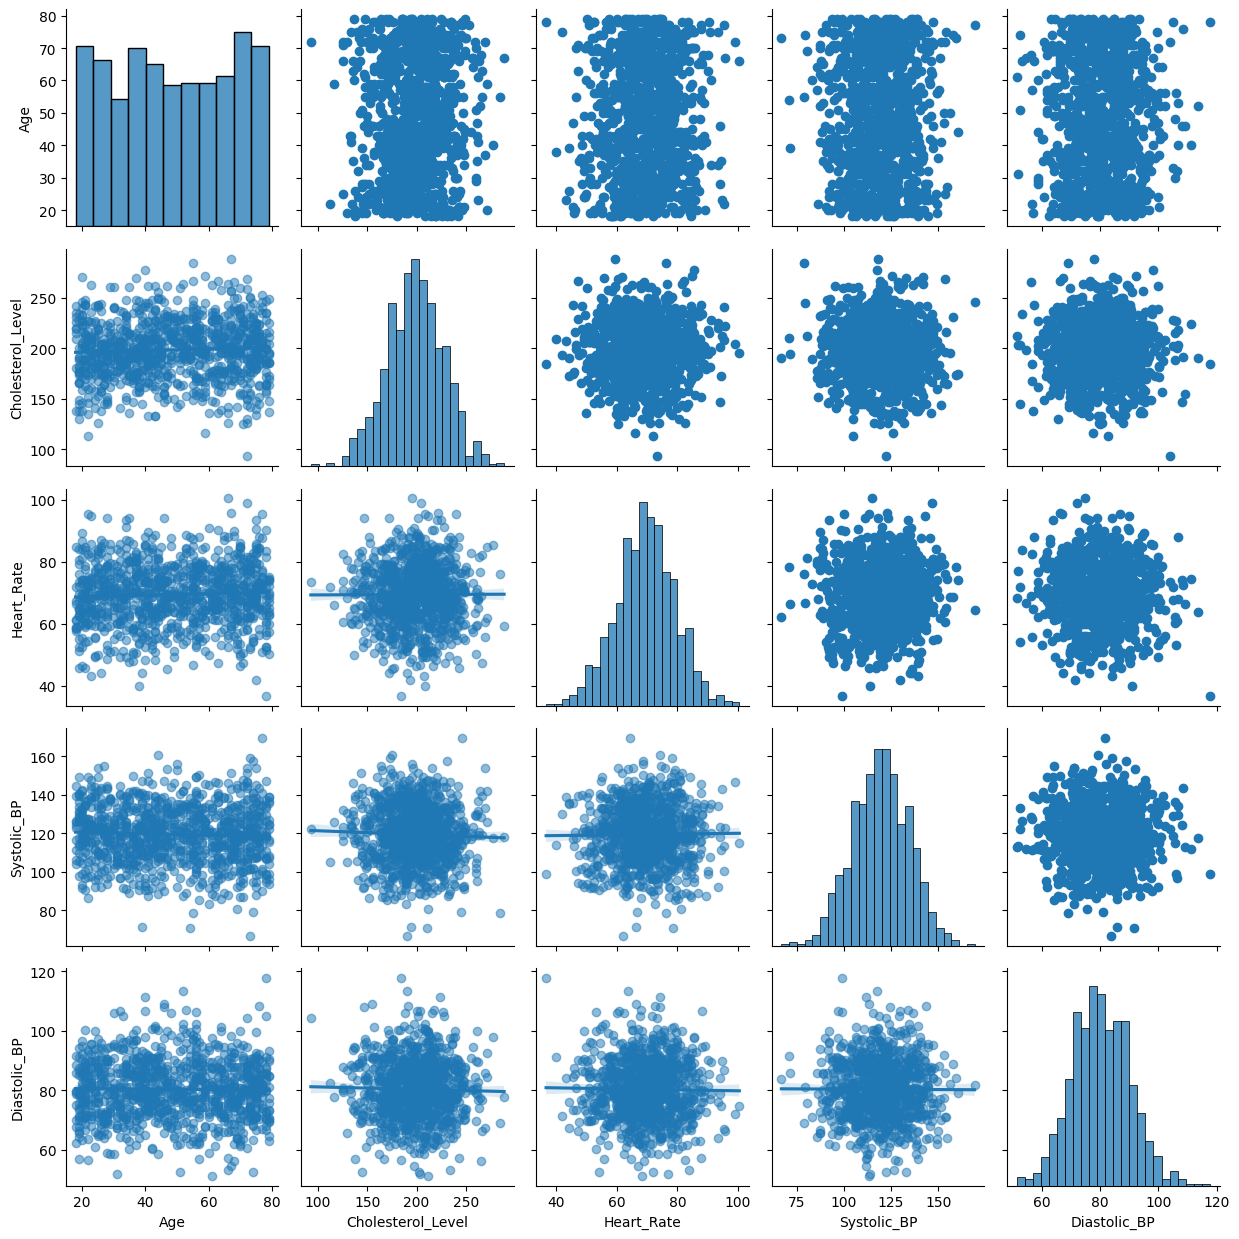

In [ ]:
# Create a pairs plot
pars = sns.PairGrid(data)
pars.map_upper(plt.scatter)
pars.map_lower(sns.regplot, scatter_kws = {'alpha':0.5})
pars.map_diag(sns.histplot)
plt.tight_layout()
plt.show()

In [ ]:
# Compute the covariance and correlation matrices

cova = data.cov()
print("Covariance Matrix:\n", cova, "\n")

corr = data.corr()
print("Correlation Matrix:\n", corr)

Covariance Matrix:
                           Age  Cholesterol_Level  Heart_Rate  Systolic_BP  \
Age                331.082834          25.605992    8.623189   -13.114972   
Cholesterol_Level   25.605992         826.956187    0.967080   -16.163039   
Heart_Rate           8.623189           0.967080   95.947369     1.888047   
Systolic_BP        -13.114972         -16.163039    1.888047   223.155291   
Diastolic_BP        -2.598082          -6.829779   -1.571614    -0.674328   

                   Diastolic_BP  
Age                   -2.598082  
Cholesterol_Level     -6.829779  
Heart_Rate            -1.571614  
Systolic_BP           -0.674328  
Diastolic_BP          99.153032   

Correlation Matrix:
                         Age  Cholesterol_Level  Heart_Rate  Systolic_BP  \
Age                1.000000           0.048936    0.048382    -0.048250   
Cholesterol_Level  0.048936           1.000000    0.003433    -0.037625   
Heart_Rate         0.048382           0.003433    1.000000     0.

According to the pairs plot and correlation, These variables just have a little relationship with each other.

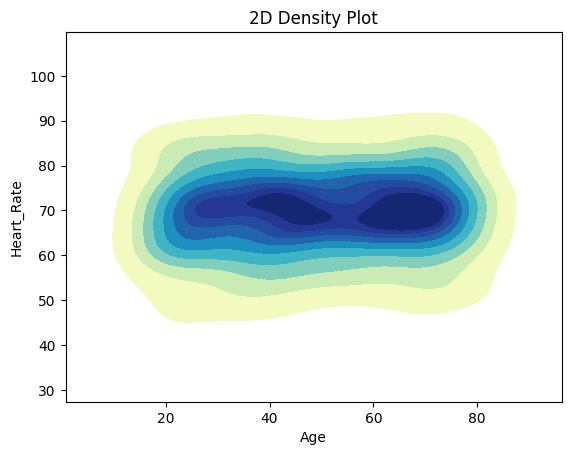

In [ ]:
# Create density plot for "Age" and "Heart_Rate"
sns.kdeplot(x = data['Age'], y = data['Heart_Rate'], cmap = "YlGnBu", fill = True)
plt.title("2D Density Plot")
plt.xlabel("Age")
plt.ylabel("Heart_Rate")
plt.show()

This plot makes sense. They have little correlation.

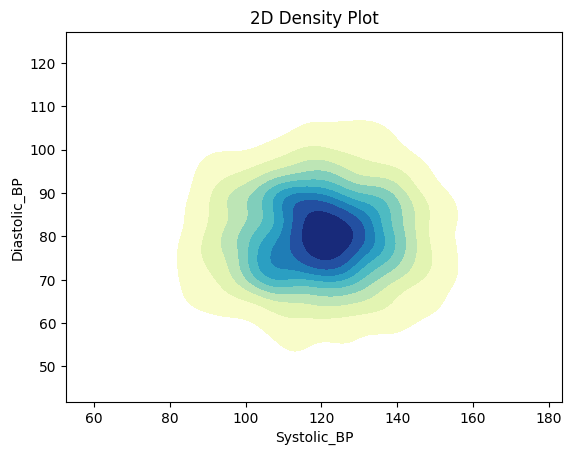

In [ ]:
# Create density plot for "Systolic_BP" and "Diastolic_BP"
sns.kdeplot(x = data['Systolic_BP'], y = data['Diastolic_BP'], cmap = "YlGnBu", fill = True)
plt.title("2D Density Plot")
plt.xlabel("Systolic_BP")
plt.ylabel("Diastolic_BP")
plt.show()

This plot makes sense. They have little correlation.

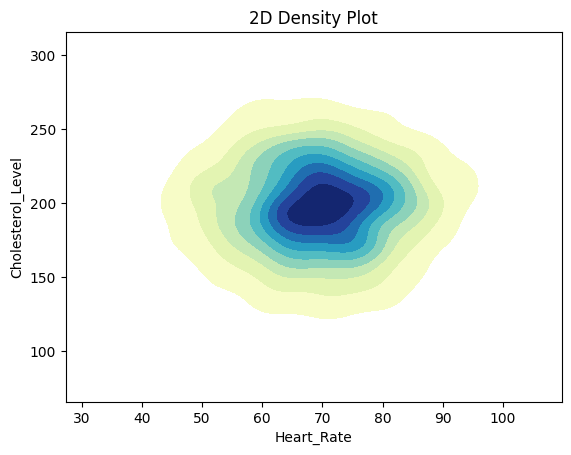

In [ ]:
# Create density plot for "Heart_Rate" and "Cholesterol_Level"
sns.kdeplot(x = data['Heart_Rate'], y = data['Cholesterol_Level'], cmap = "YlGnBu", fill = True)
plt.title("2D Density Plot")
plt.xlabel("Heart_Rate")
plt.ylabel("Cholesterol_Level")
plt.show()

This plot makes sense. They have little correlation.

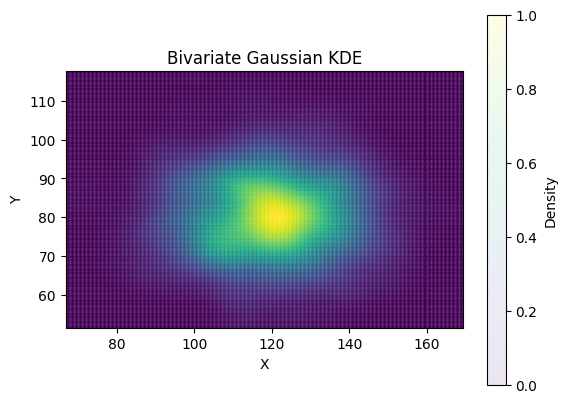

In [ ]:
# Use Gaussian KDE

# Combine two variables
comb = np.vstack([data['Systolic_BP'], data['Diastolic_BP']])
kde = gaussian_kde(comb)

# Create grid
xmin, xmax = data['Systolic_BP'].min(), data['Systolic_BP'].max()
ymin, ymax = data['Diastolic_BP'].min(), data['Diastolic_BP'].max()
x, y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]

# Compute density
z = np.reshape(kde(np.vstack([x.ravel(), y.ravel()])).T, x.shape)

plt.imshow(z.T, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='viridis')
plt.scatter(x, y, c='white', alpha=0.1, s=1)
plt.colorbar(label='Density')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Bivariate Gaussian KDE')
plt.show()


In [ ]:
a, b, c, d, e = data["Age"], data["Cholesterol_Level"], data["Heart_Rate"], data["Systolic_BP"], data["Diastolic_BP"]

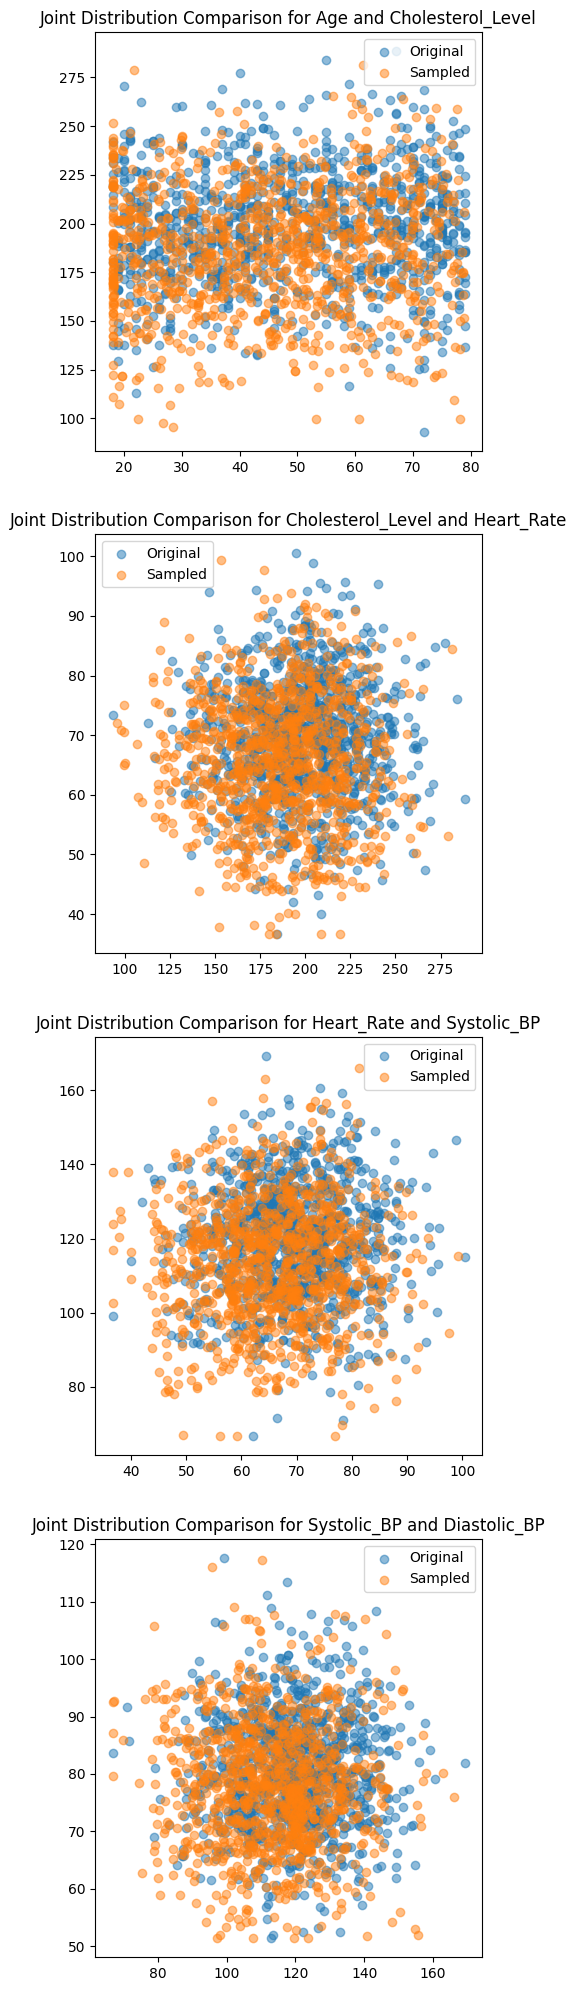

In [ ]:
# Create new samples for all the five variables together

# Get PDF of joint distribution
data = np.vstack([a, b, c, d, e])
kde = gaussian_kde(data)

# Create grid
a_grid = np.linspace(min(a), max(a), 10)
b_grid = np.linspace(min(b), max(b), 10)
c_grid = np.linspace(min(c), max(c), 10)
d_grid = np.linspace(min(d), max(d), 10)
e_grid = np.linspace(min(e), max(e), 10)
A, B, C, D, E = np.meshgrid(a_grid, b_grid, c_grid, d_grid, e_grid)
positions = np.vstack([A.ravel(), B.ravel(), C.ravel(), D.ravel(), E.ravel()])

# Estimate joint PDF at grid points
Z = np.reshape(kde(positions), A.shape)

# Sample using conditional distribution approach
n_samples = 1000
samples = np.zeros((5, n_samples))
for i in range(n_samples):
    # Sample a marginal
    u1 = np.random.uniform()
    a_pdf = np.sum(Z, axis=(0, 2, 3, 4))
    a_cdf = np.cumsum(a_pdf) * (a_grid[1] - a_grid[0])
    a_cdf = a_cdf / a_cdf[-1]
    a_sample = np.interp(u1, a_cdf, a_grid)

    # Sample b conditional on a
    idxa = np.abs(a_grid - a_sample).argmin()
    b_pdf = np.sum(Z[:, idxa, :, :, :], axis=(1, 2, 3))
    b_cdf = np.cumsum(b_pdf) * (b_grid[1] - b_grid[0])
    b_cdf = b_cdf / b_cdf[-1]
    u2 = np.random.uniform()
    b_sample = np.interp(u2, b_cdf, b_grid)

    # Sample c conditional on a and b
    idxb = np.abs(b_grid - b_sample).argmin()
    c_pdf = np.sum(Z[idxb, idxa, :, :, :], axis=(1, 2))
    c_cdf = np.cumsum(c_pdf) * (c_grid[1] - c_grid[0])
    c_cdf = c_cdf / c_cdf[-1]
    u3 = np.random.uniform()
    c_sample = np.interp(u3, c_cdf, c_grid)

    # Sample d conditional on a, b and c
    idxc = np.abs(c_grid - c_sample).argmin()
    d_pdf = np.sum(Z[idxb, idxa, idxc, :, :], axis=1)
    d_cdf = np.cumsum(d_pdf) * (d_grid[1] - d_grid[0])
    d_cdf = d_cdf / d_cdf[-1]
    u4 = np.random.uniform()
    d_sample = np.interp(u4, d_cdf, d_grid)

    # Sample e conditional on a, b, c and d
    idxd = np.abs(d_grid - d_sample).argmin()
    e_pdf = Z[idxb, idxa, idxc, idxd, :]
    e_cdf = np.cumsum(e_pdf) * (e_grid[1] - e_grid[0])
    e_cdf = e_cdf / e_cdf[-1]
    u5 = np.random.uniform()
    e_sample = np.interp(u5, e_cdf, e_grid)

    samples[:, i] = [a_sample, b_sample, c_sample, d_sample, e_sample]

# Plot results
plt.figure(figsize=(5, 25))
plt.subplot(411)
plt.scatter(a, b, alpha=0.5, label='Original')
plt.scatter(samples[0], samples[1], alpha=0.5, label='Sampled')
plt.legend()
plt.title('Joint Distribution Comparison for Age and Cholesterol_Level')

plt.subplot(412)
plt.scatter(b, c, alpha=0.5, label='Original')
plt.scatter(samples[1], samples[2], alpha=0.5, label='Sampled')
plt.legend()
plt.title('Joint Distribution Comparison for Cholesterol_Level and Heart_Rate')

plt.subplot(413)
plt.scatter(c, d, alpha=0.5, label='Original')
plt.scatter(samples[2], samples[3], alpha=0.5, label='Sampled')
plt.legend()
plt.title('Joint Distribution Comparison for Heart_Rate and Systolic_BP')

plt.subplot(414)
plt.scatter(d, e, alpha=0.5, label='Original')
plt.scatter(samples[3], samples[4], alpha=0.5, label='Sampled')
plt.legend()
plt.title('Joint Distribution Comparison for Systolic_BP and Diastolic_BP')
plt.show()